# 1812 Overture finale, scored (not audio) as fireworks and bells over Moscow at night.

REVISION: the first version represented the hymn "God Save the Tsar" as a flat swelling glow with no pitch data at all -- which is exactly why it read as generic fireworks clip art rather than translated music. Fixed by reading the actual Lvov anthem transcription (a clean monophonic score, flutetunes.com) and tracing its real melodic arc -- a phrase that opens on a repeated high note, dips, leaps to a peak, and cadences down (heard twice), then a rising middle section building to the highest point in the piece, then the opening idea returns to close -- as a real glowing line across the sky, the same way ode_to_joy's terrain height IS its melody. Also removed an earlier fabricated claim: the first draft had the 11 cannon shots' spacing compress together over time, implying a verified accelerando that was never actually sourced. They're spaced evenly now; the only verified facts driving this piece are the shot count (11 of 16 total; the other 5 are at the earlier Borodino sequence, out of scope) and the hymn's real melodic contour. Church bells remain a later performance tradition, not literally in Tchaikovsky's original score, though understood.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Polygon

N_SHOTS = 11
N_BELL_TOWERS = 4
FIGSIZE = (18, 5.2)

SKY_NIGHT = np.array([0.04, 0.05, 0.12])
SKY_GLOW = np.array([0.45, 0.26, 0.09])  # warm triumphant gold, mixed in as the hymn swells
SKYLINE_COLOR = "#0a0a14"
BELL_RING_COLOR = "#ffe9a8"
BURST_COLOR = "#fff2c9"
BURST_COLOR2 = "#ffcf7a"
HYMN_COLOR = "#ffe27a"

# "God Save the Tsar" (Lvov), real melodic arc read off the flutetunes.com transcription:
# phrase opens on a repeated high note, dips, leaps to a peak, cadences down -- heard twice --
# then a rising middle section building to the highest point in the piece, then the opening
# phrase returns to close. Relative contour (not absolute pitch), since what matters here is
# the real shape, not the key.
PHRASE_A = [10, 10, 9, 8, 7, 6, 5, 12, 12, 11, 9, 8, 7, 6, 5]
PHRASE_B = [6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 14, 13]
PHRASE_A_RETURN = PHRASE_A + [3]
HYMN_CONTOUR = PHRASE_A + PHRASE_A + PHRASE_B + PHRASE_A_RETURN
HYMN_NORM = (np.array(HYMN_CONTOUR) - min(HYMN_CONTOUR)) / (max(HYMN_CONTOUR) - min(HYMN_CONTOUR))


def build_timeline():
    xs = np.linspace(1.2, 13.6, N_SHOTS)  # even spacing -- exact shot timing wasn't verified
    return xs, xs[-1] + 1.8


SHOT_X, WIDTH = build_timeline()
PROGRESS = (SHOT_X - SHOT_X.min()) / (SHOT_X.max() - SHOT_X.min())
# a patch that is `width_data` == `height_data` renders stretched on these axes, since
# 1 x-unit and 1 y-unit map to very different pixel counts (learned the hard way in
# fate_motif_storm's Circle-vs-Ellipse bug) -- compute the real correction instead of
# guessing a ratio, so a "radius r" patch actually looks round on screen
ASPECT = (FIGSIZE[1] * WIDTH) / (FIGSIZE[0] * 1.0)


def circle(xy, r, **kwargs):
    return Ellipse(xy, width=2 * r * ASPECT, height=2 * r, **kwargs)

## Render: night sky, the real hymn melody, Moscow skyline, pealing bells, and the cannon-shot fireworks

In [2]:
def draw_sky(ax):
    hw, hh = 500, 200
    col_progress = np.clip(np.linspace(0, WIDTH, hw) / WIDTH, 0, 1) ** 1.4
    rgb = SKY_NIGHT[None, :] + (SKY_GLOW - SKY_NIGHT)[None, :] * col_progress[:, None] * 0.75
    img = np.tile(rgb[None, :, :], (hh, 1, 1))
    ax.imshow(img, extent=(0, WIDTH, 0, 1), origin="lower", aspect="auto", zorder=0)


def dome_tower(ax, x, height, width, color=SKYLINE_COLOR):
    ax.add_patch(Polygon([(x - width / 2, 0), (x - width / 2, height * 0.55),
                          (x + width / 2, height * 0.55), (x + width / 2, 0)],
                         closed=True, color=color, zorder=6))
    ax.add_patch(circle((x, height * 0.55), width * 0.62, color=color, zorder=6))
    ax.plot([x, x], [height * 0.75, height], color=color, linewidth=2.2, zorder=6)


def draw_skyline(ax, bell_xs):
    rng = np.random.default_rng(3)
    n = 70
    xs = np.linspace(0, WIDTH, n)
    heights = 0.09 + 0.05 * rng.random(n)
    bar_w = WIDTH / n
    for x, h in zip(xs, heights):
        ax.add_patch(Polygon([(x, 0), (x, h), (x + bar_w, h), (x + bar_w, 0)],
                              closed=True, color=SKYLINE_COLOR, zorder=5))
    for bx in bell_xs:
        dome_tower(ax, bx, height=0.30 + 0.04 * rng.random(), width=0.6)


def bell_rings(ax, x, base_y, n_rings=6, max_r=0.55, alpha_scale=0.5):
    for i in range(n_rings):
        r = max_r * (i + 1) / n_rings
        a = alpha_scale * (1 - i / n_rings)
        ax.add_patch(circle((x, base_y), r, fill=False, edgecolor=BELL_RING_COLOR,
                             linewidth=1.4, alpha=a, zorder=3))


def draw_hymn(ax):
    """The real melody, traced as a glowing line -- this piece's actual `terrain height IS
    the melody` element, the thing the first draft skipped entirely."""
    n = len(HYMN_NORM)
    xs = np.linspace(WIDTH * 0.08, WIDTH * 0.95, n)
    ys = 0.62 + 0.32 * HYMN_NORM
    # brightness builds through the real mf->f rise in phrase B (the piece's actual climax),
    # not a fabricated timeline ramp
    brightness = 0.4 + 0.6 * HYMN_NORM
    for i in range(n - 1):
        ax.plot(xs[i:i + 2], ys[i:i + 2], color=HYMN_COLOR, linewidth=2.2,
                alpha=0.5 + 0.4 * brightness[i], zorder=2, solid_capstyle="round")
    for x, y, b in zip(xs, ys, brightness):
        ax.add_patch(circle((x, y), 0.05 + 0.05 * b, color=HYMN_COLOR, alpha=0.10 + 0.12 * b,
                             zorder=2, linewidth=0))


def firework_burst(ax, x, y, size, brightness, seed):
    rng = np.random.default_rng(seed)
    for ang in np.linspace(0, 2 * np.pi, 16, endpoint=False):
        length = size * (0.7 + 0.5 * rng.random())
        dx, dy = length * np.cos(ang), length * np.sin(ang)
        ax.plot([x, x + dx * ASPECT], [y, y + dy], color=BURST_COLOR2, linewidth=1.6,
                alpha=0.35 * brightness, zorder=8, solid_capstyle="round")
    for scale, a, c in [(2.0, 0.12, BURST_COLOR2), (1.1, 0.35, BURST_COLOR2), (0.45, 0.9, BURST_COLOR)]:
        ax.add_patch(circle((x, y), size * scale, color=c, alpha=a * brightness, zorder=9, linewidth=0))

saved overture_1812_finale.png


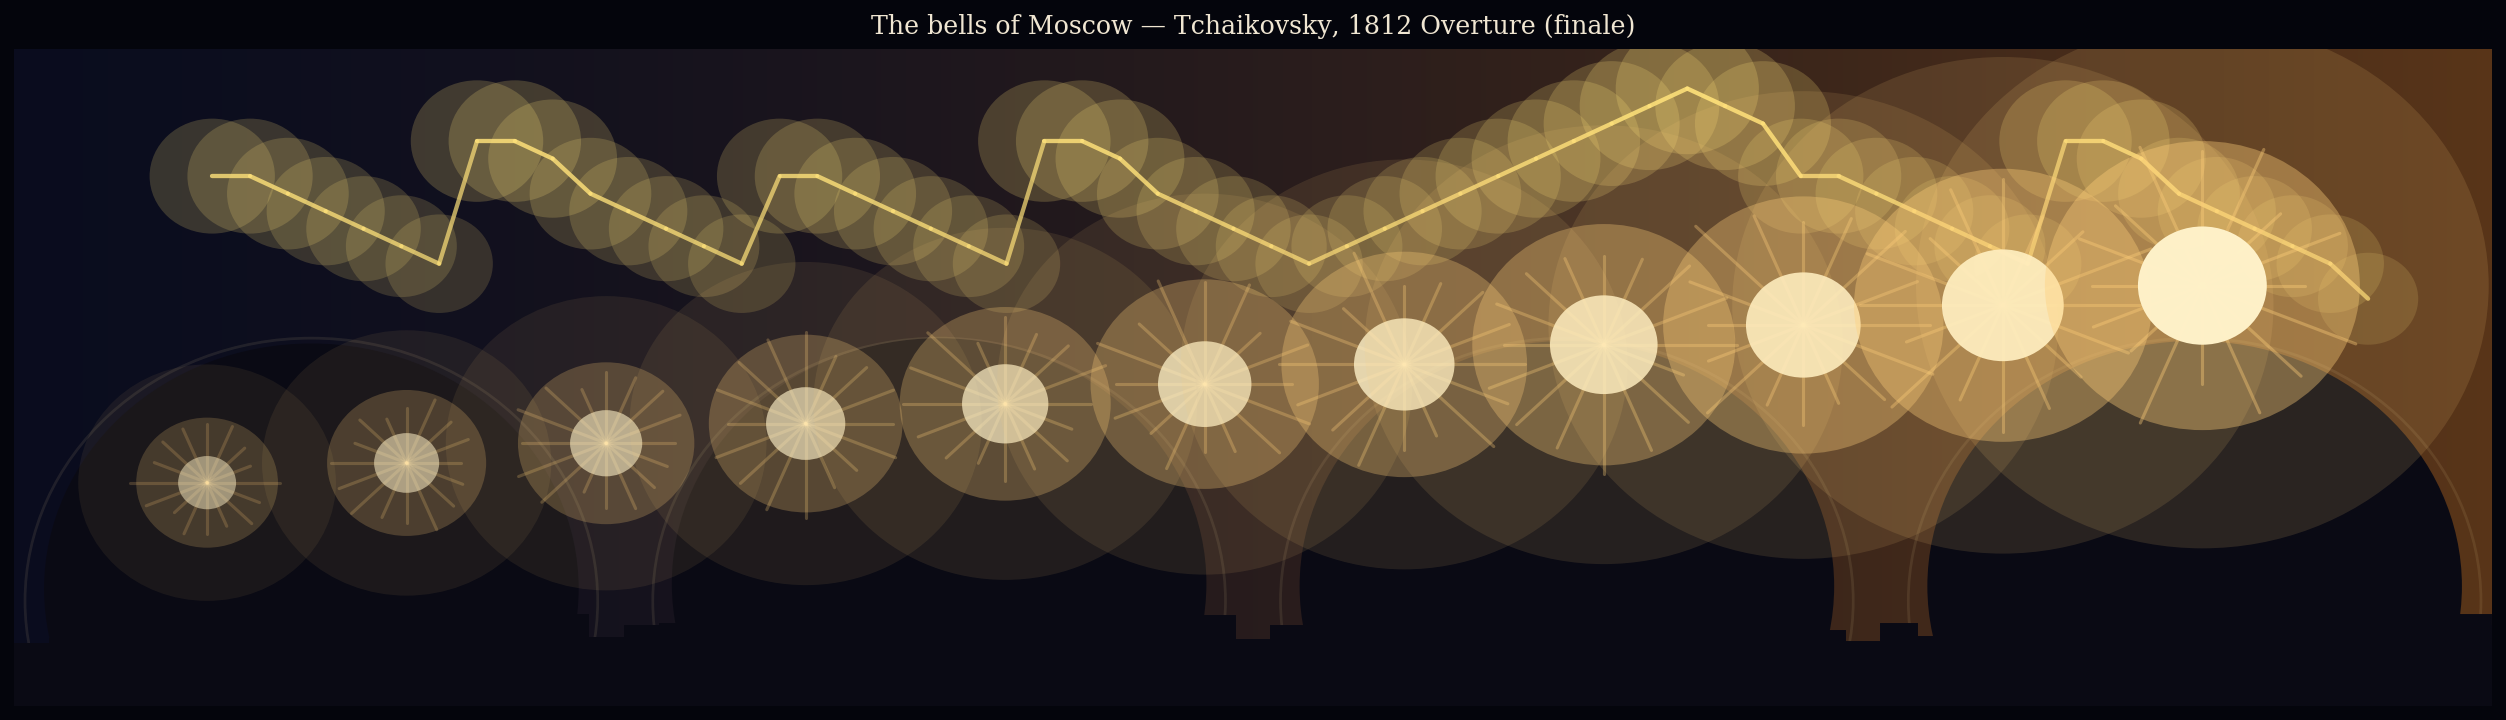

In [3]:
def render(out_path="overture_1812_finale.png"):
    fig, ax = plt.subplots(figsize=FIGSIZE, dpi=140)
    bell_xs = np.linspace(WIDTH * 0.12, WIDTH * 0.88, N_BELL_TOWERS)
    draw_sky(ax)
    draw_hymn(ax)

    # bells peal steadily through the whole finale, independent of the cannon rhythm
    for bx in bell_xs:
        bell_rings(ax, bx, 0.16, n_rings=6, max_r=0.40, alpha_scale=0.55)

    draw_skyline(ax, bell_xs)

    for x, p in zip(SHOT_X, PROGRESS):
        y = 0.34 + 0.30 * p
        size = 0.09 + 0.11 * p
        brightness = 0.55 + 0.55 * p
        firework_burst(ax, x, y, size, brightness, seed=int(x * 100))

    ax.set_xlim(0, WIDTH)
    ax.set_ylim(0, 1)
    ax.axis("off")
    fig.suptitle("The bells of Moscow — Tchaikovsky, 1812 Overture (finale)",
                 fontsize=13, color="#f0e6d2", y=0.98, fontfamily="serif")
    fig.patch.set_facecolor("#04050c")
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    fig.savefig(out_path, facecolor=fig.get_facecolor())
    print("saved", out_path)


render()

## Takeaways

- Simon's critique applied here too: the first version represented the hymn "God Save the Tsar" as a flat swelling glow with zero pitch data, which is why it read as generic fireworks-over-a-city clip art rather than translated music, no different in kind from William Tell's flat gallop bounce.
- Fixed by finding a clean monophonic transcription of the actual Lvov anthem (flutetunes.com) and tracing its real melodic arc -- opens on a repeated high note, dips, leaps to a peak, cadences down (heard twice), a rising middle section building to the highest point in the piece, then the opening idea returns to close -- as a glowing line across the sky. Now the piece has the same "terrain height IS the melody" property `ode_to_joy_landscape` has.
- Also removed a fabricated claim from the first draft: the 11 cannon shots' spacing compressed together over time, implying a verified accelerando in the score that was never actually sourced. They're evenly spaced now -- the only things this piece asserts as real are the shot count (11 of 16 total) and the hymn's actual melodic contour.
- Third recurrence of the same root lesson across this series: a verified *rhythm* or *count* is not the same as a verified *melody*, and only the melody is what makes a static image read as translated music rather than a themed illustration.